Cells must be run in order.

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import warnings
import matplotlib.ticker as ticker
from matplotlib import cm
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# custom
import functions as functions

# Ignore specific warnings from scipygit
warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")

pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Initialize

Name of political dimensions.

In [2]:
Dimensions = ['Left-Right', 'Immigration', 'Environment', 'Social liberalism', 'Redistribution','Anti-elitism', 'EU integration', 'Direct democracy']

Data path.

In [3]:
data_path = 'data/'

Path to ESS results obtained in R.

In [4]:
ess_path = 'ESS_results/'

## Esthetics

Where to save figures.

In [5]:
figpath  = './plots/'

Define general Matplotlib style.

In [6]:
def reset_plot_style():
    
    mpl.style.use('seaborn-v0_8-whitegrid')  # or 'ggplot', 'bmh', 'fivethirtyeight'
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.bottom'] = True
    plt.rcParams['axes.spines.left'] = True

    plt.rcParams['axes.grid'] = False
    mpl.rcParams['mathtext.fontset'] = 'stix'
    mpl.rcParams['font.family'] = 'Lato' #'STIXGeneral'

    # font size
    mpl.rcParams['axes.labelsize'] = 16
    mpl.rcParams['xtick.labelsize'] = 14
    mpl.rcParams['ytick.labelsize'] = 14
    mpl.rcParams['legend.fontsize'] = 14
    mpl.rcParams['legend.title_fontsize'] = 18
    mpl.rcParams['figure.titlesize'] = 18
    mpl.rcParams['axes.titlesize'] = 18

    # ticks
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['xtick.top'] = False
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = False
    plt.rcParams['xtick.major.size'] = 6
    plt.rcParams['ytick.major.size'] = 6
    plt.rcParams['xtick.major.width'] = 1
    plt.rcParams['ytick.major.width'] = 1
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'

In [7]:
reset_plot_style()

Define a color for each data source.

In [8]:
cmap = plt.get_cmap('rainbow_r')
df_color = {'X': cmap(0), 'ESS': cmap(.75)}

Labeling dimensions for plots.

In [9]:
axis_label_neg = {'Left-Right': 'Left', 'EU integration': 'EU+', 'Immigration':'Immig+', 'Anti-elitism':'Elitist',
                'Social liberalism': 'SocLib+', 'Environment': 'Env+', 'Redistribution': 'Redist+',
                'Direct democracy': 'DirDem-'}

axis_label_pos = {'Left-Right': 'Right', 'EU integration': 'EU-', 'Immigration':'Immig-', 'Anti-elitism':'Anti-elite',
                'Social liberalism': 'SocLib-', 'Environment': 'Env-', 'Redistribution': 'Redist-',
                'Direct democracy': 'DirDem+'}

axis_label = {'Left-Right':'Left <---> Right', 'Immigration':'Pro <---> Anti', 'Environment':'Pro <---> Anti', 'Social liberalism':'Pro <---> Anti',
          'Anti-elitism':'Elitist <---> Anti-elite', 'EU integration':'Pro <---> Anti', 'Direct democracy':'Anti <---> Pro', 'Redistribution':'Pro <---> Anti'}

Labels for data sources.

In [10]:
DataLabel = {'X':'X panel', 'ESS':'ESS panel'}

Choose markers.

In [11]:
Marker = {'X':'o', 'ESS':'s'}

Short labels for political dimensions.

In [12]:
short_label = {'Left-Right':'LR',
'Immigration':'Immig',
'Environment':'Env',
'Social liberalism': 'SocLib',
'Redistribution':'Redist',
'Anti-elitism':'AE',
'EU integration':'EU',
'Direct democracy':'DirDem'}

## Load and pre-process X data

Get political positions of users.

In [13]:
df_x = pd.read_csv(data_path + 'followers_positions.csv')

In [14]:
df_x

,pseudo_id,lrgen_19,corrupt_salience_19,people_vs_elite_19,immigrate_policy_19,sociallifestyle_19,nationalism_19,antielite_salience_23,eu_position_23,lrecon_23,refugees_23,galtan_23,environment_19,lrecon_19,antielite_salience_19,eu_position_19,galtan_19
0,user_0,3.015,5.360,6.196,5.458,3.124,4.525,8.137,4.242,3.677,6.458,4.187,4.624,2.291,9.431,3.117,4.637
1,user_1,3.079,4.338,5.188,4.006,2.234,3.938,6.658,4.847,3.113,6.761,3.778,3.662,2.575,6.832,5.085,3.866
2,user_2,9.582,4.604,4.014,9.579,9.070,9.683,8.375,2.582,6.935,2.867,9.189,6.834,7.869,7.080,2.916,8.581
3,user_3,3.187,5.358,6.063,5.693,3.332,4.719,7.942,4.410,4.028,6.409,4.451,4.877,2.428,9.490,3.015,4.828
4,user_4,5.509,5.433,5.545,7.473,5.509,6.866,8.448,3.484,5.236,4.713,6.477,5.829,4.153,9.458,2.094,6.456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,4.711,5.210,5.405,3.447,4.513,6.652,5.345,4.378,7.078,4.362,4.990,3.232,7.837,4.601,4.694
978046,user_978929,7.794,5.112,5.047,7.077,6.005,6.428,5.778,5.717,6.000,6.321,6.099,5.633,6.819,5.966,6.506,5.853
978047,user_978930,7.932,4.493,4.144,7.498,6.721,7.037,5.928,5.403,6.518,5.753,6.793,6.042,7.100,5.616,6.088,6.473
978048,user_978931,3.680,5.556,6.027,6.512,4.080,5.524,8.410,3.926,4.545,5.754,5.264,5.402,2.695,10.142,2.104,5.503


Restrict to variables of interest and rename political dimensions.

In [15]:
VariableName = {'lrgen_19': 'Left-Right', 
                'antielite_salience_23': 'Anti-elitism', 
                'eu_position_23': 'EU integration', 
                'sociallifestyle_19': 'Social liberalism', 
                'environment_19': 'Environment', 
                'immigrate_policy_19': 'Immigration',
                'people_vs_elite_19': 'Direct democracy', 
                'lrecon_23': 'Redistribution'}

In [16]:
df_x = df_x[['pseudo_id'] + list(VariableName.keys())]

In [17]:
df_x = df_x.rename(columns = {var: name for var,name in VariableName.items()})

Rescale outliers.

In [18]:
print('Percentage of outliers')
for dim in Dimensions:
    percent_outliers = 100*((df_x[dim]<0) | (df_x[dim]>10)).sum() / df_x.shape[0]
    print(dim,  percent_outliers)
    df_x.loc[df_x[dim]<0, dim] = 0
    df_x.loc[df_x[dim]>10, dim] = 10

Percentage of outliers
Left-Right 3.080824088748019
Immigration 4.010633403200245
Environment 0.18986759368130462
Social liberalism 0.5901538776136189
Redistribution 0.03271816369306273
Anti-elitism 2.082817851848065
EU integration 0.9201983538673892
Direct democracy 0.022595981800521445


In [19]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution
0,user_0,3.015,8.137,4.242,3.124,4.624,5.458,6.196,3.677
1,user_1,3.079,6.658,4.847,2.234,3.662,4.006,5.188,3.113
2,user_2,9.582,8.375,2.582,9.070,6.834,9.579,4.014,6.935
3,user_3,3.187,7.942,4.410,3.332,4.877,5.693,6.063,4.028
4,user_4,5.509,8.448,3.484,5.509,5.829,7.473,5.545,5.236
...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,5.345,3.447,4.990,5.405,5.210,4.378
978046,user_978929,7.794,5.778,5.717,6.005,5.633,7.077,5.047,6.000
978047,user_978930,7.932,5.928,5.403,6.721,6.042,7.498,4.144,6.518
978048,user_978931,3.680,8.410,3.926,4.080,5.402,6.512,6.027,4.545


Reverse EU integration ordering.

In [20]:
df_x['EU integration'] = 10.0 - df_x['EU integration']

Get activity and popularity metrics.

In [21]:
df_actipop = pd.read_csv(data_path + 'followers_activity.csv')

Merge with political positions.

In [22]:
df_x = df_x.merge(df_actipop, on='pseudo_id')

In [23]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution,mean_tweets_per_day,followers,followees
0,user_0,3.015,8.137,5.758,3.124,4.624,5.458,6.196,3.677,1.272,47,292
1,user_1,3.079,6.658,5.153,2.234,3.662,4.006,5.188,3.113,0.000,1,62
2,user_2,9.582,8.375,7.418,9.070,6.834,9.579,4.014,6.935,0.000,0,105
3,user_3,3.187,7.942,5.590,3.332,4.877,5.693,6.063,4.028,0.001,0,509
4,user_4,5.509,8.448,6.516,5.509,5.829,7.473,5.545,5.236,0.070,66,263
...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,4.655,3.447,4.990,5.405,5.210,4.378,0.031,113,692
978046,user_978929,7.794,5.778,4.283,6.005,5.633,7.077,5.047,6.000,0.011,9,5002
978047,user_978930,7.932,5.928,4.597,6.721,6.042,7.498,4.144,6.518,0.057,36,131
978048,user_978931,3.680,8.410,6.074,4.080,5.402,6.512,6.027,4.545,0.063,12,191


In [24]:
print('Number of rows containing NaNs: ', df_x.isna().any(axis=1).sum())

Number of rows containing NaNs:  0


Drop followees column (unused).

In [25]:
df_x = df_x.drop(columns='followees')

Clean memory: delete activity and popularity df.

In [26]:
del df_actipop

## Load ESS data

In [27]:
df_ess = pd.read_csv(data_path + 'ESS11_preprocessed.csv')

Range of values along each dimension.

In [28]:
ess_label_range = {
        "Direct democracy": [1, 2, 3, 4, 5],
        "Environment": [1, 2, 3, 4, 5, 6],
        "Left-Right": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "EU integration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Anti-elitism": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Immigration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Social liberalism": [1, 2, 3, 4, 5],
        "Redistribution": [1, 2, 3, 4, 5],
        "Online political actiivty": [1,2]
    }

Load weighted counts of respondent.

In [29]:
ess_path = 'ESS_results/'

In [30]:
ess_counts_full = pd.read_csv(ess_path + 'weighted_counts_by_variable.csv')

In [31]:
ess_counts_full['variable'] = [d.replace('.', ' ') for d in ess_counts_full['variable'].values]
ess_counts_full['variable'] = ess_counts_full['variable'].replace({'Left Right':'Left-Right',
                                                                    'Anti elitism':'Anti-elitism'
                                                                    })

Load correlation matrix.

In [32]:
corrmat_ESS = pd.read_csv(ess_path + 'Corr_matrix.csv')

In [33]:
corrmat_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in corrmat_ESS['Unnamed: 0'].values]
corrmat_ESS['Unnamed: 0'] = corrmat_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
corrmat_ESS = corrmat_ESS.set_index(corrmat_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
corrmat_ESS.columns = corrmat_ESS.index

In [34]:
corrmat_ESS

,Left-Right,Immigration,Environment,Social liberalism,Redistribution,Anti-elitism,EU integration,Direct democracy
Left-Right,1.000,0.389,0.160,0.112,0.245,-0.002,0.167,0.056
Immigration,0.389,1.000,0.117,0.064,0.101,0.202,0.263,0.230
Environment,0.160,0.117,1.000,0.067,0.130,0.027,0.109,-0.018
Social liberalism,0.112,0.064,0.067,1.000,0.113,-0.059,0.040,0.026
Redistribution,0.245,0.101,0.130,0.113,1.000,-0.047,-0.003,-0.090
Anti-elitism,-0.002,0.202,0.027,-0.059,-0.047,1.000,0.271,0.406
EU integration,0.167,0.263,0.109,0.040,-0.003,0.271,1.000,0.246
Direct democracy,0.056,0.230,-0.018,0.026,-0.090,0.406,0.246,1.000


Load p-values of correlation matrix.

In [35]:
pval_ESS = pd.read_csv(ess_path + 'Corr_pval.csv')

In [36]:
pval_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in pval_ESS['Unnamed: 0'].values]
pval_ESS['Unnamed: 0'] = pval_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                         'Anti elitism':'Anti-elitism'})
pval_ESS = pval_ESS.set_index(pval_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
pval_ESS.columns = pval_ESS.index

# Distribution of panelists along political dimensions
Figure 1.

Discretize X panelists.

In [37]:
for dim in Dimensions:
    df_x[dim + '_bin'] = functions.discretized(df_x, dim, ess_label_range)

Plots distributions.

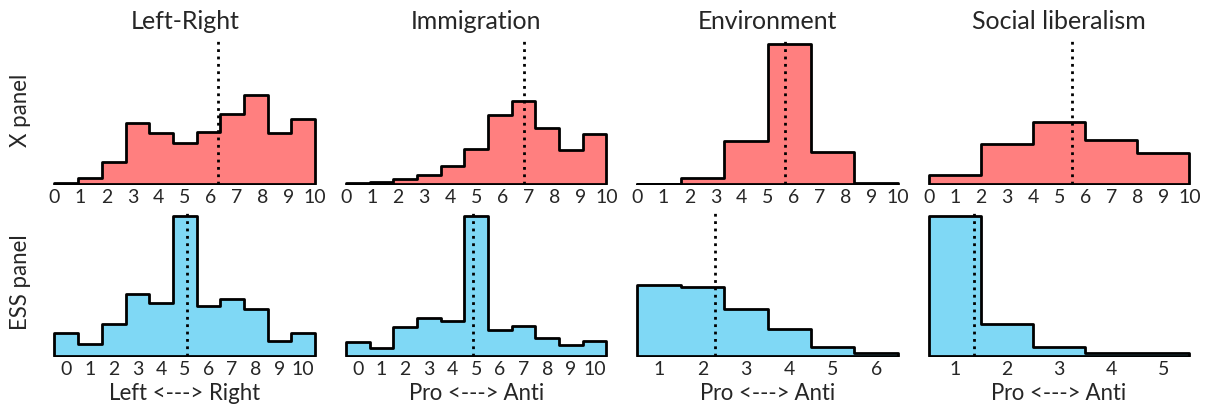

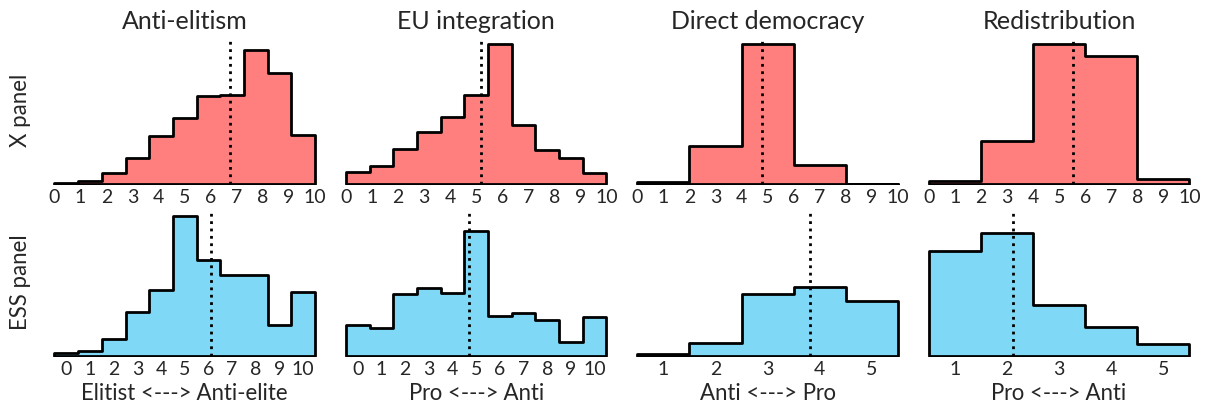

In [38]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Get the mass in each bin
        Counts['X'] = functions.get_x_counts(df_x, dim)
        Counts['ESS'] = functions.get_ess_counts(ess_counts_full, dim)

        for j,label in enumerate(('X', 'ESS')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot histogram
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label], edgecolor='none', discrete=True, alpha=.5, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', discrete=True, alpha=1, ax=ax)

            # xticks for X panel
            if label=='X':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            # esthetics
            if j==1:
                ax.set_xticks(ess_label_range[dim])
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            # axe lines
            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    plt.tight_layout(pad=.2)
    plt.savefig(figpath + f'histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Compute and show Wasserstein distance between X and ESS panel for each dimension.

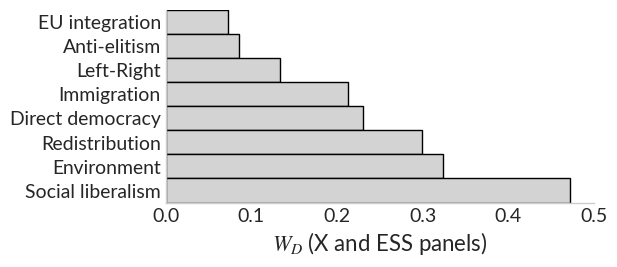

In [39]:
WD = dict()

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_counts_full, dim)

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    WD[dim] = wd / wd_max
    
# Step 2: Set y='Dimension' as a categorical with the right order
dimension_order = [dim for dim,wd in sorted(WD.items(), key=lambda x:x[1])]

plot_data = pd.DataFrame({'Dimension':WD.keys(), 'WD':WD.values()})
plot_data['Dimension'] = pd.Categorical(
    plot_data['Dimension'], 
    categories=dimension_order, 
    ordered=True
)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
sns.barplot(data=plot_data, y='Dimension', x='WD', color='lightgrey', width=1, edgecolor='k')

# esthetics
plt.ylabel('')
plt.xlim(0,.5)
plt.tick_params(length=0)
plt.xlabel(fr'$W_D$ (X and ESS panels)')
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'WD.png', dpi=300)
plt.show()
plt.close()

Compute and show polarization along each dimension.

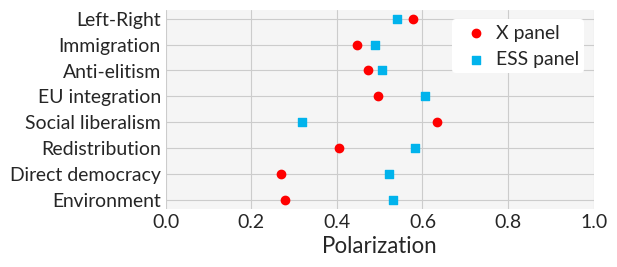

In [40]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_ess = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_counts_full, dim)

    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_ess = functions.polarization_from_counts_df(ess_counts)

    # append
    data_x['Dimension'].append(dim)
    data_ess['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_ess['Polarization'].append(pola_ess)

# create dfs
data_x = pd.DataFrame(data_x)
data_ess = pd.DataFrame(data_ess)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], label=DataLabel['X'])
plt.scatter(data_ess['Polarization'], data_ess['Dimension'], color=df_color['ESS'], marker=Marker['ESS'], label=DataLabel['ESS'])

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
plt.legend(frameon=True, framealpha=1, edgecolor='none', loc='best', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.xlim(0,1)
plt.yticks(range(xaxis.size), data_x['Dimension'].values)
plt.tick_params(length=0)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'polarization.png', dpi=300)
plt.show()
plt.close()

# Analysis of correlations
Figure 2.

Get pvalues of correlations for X panel.

In [41]:
Dimensions_reordered = ['Left-Right', 'Immigration', 'Environment', 'Redistribution', 'Social liberalism', 'Anti-elitism', 'EU integration', 'Direct democracy']

In [42]:
pval_x = np.zeros((len(Dimensions_reordered), len(Dimensions_reordered)))
for i1,dim1 in enumerate(Dimensions_reordered):
    for i2,dim2 in enumerate(Dimensions_reordered):
        if i1<i2:
            stat, pval = stats.pearsonr(df_x[dim1].values, df_x[dim2].values)
            pval_x[i1,i2] = pval_x[i2,i1] = pval
pval_x = pd.DataFrame(pval_x)
pval_x.index = Dimensions_reordered
pval_x.columns = Dimensions_reordered

In [43]:
df_corr = {'X': df_x[Dimensions_reordered].corr(), 'ESS':corrmat_ESS[Dimensions_reordered].reindex(Dimensions_reordered)}

df_pval = {'X': pval_x, 'ESS':pval_ESS[Dimensions_reordered].reindex(Dimensions_reordered)}

Create matrix with significance levels.

In [44]:
significance_matrix = dict()

for name in ('X', 'ESS'):

    significance_matrix[name] = pd.DataFrame('', index=df_pval[name].index, columns=df_pval[name].columns)
    significance_matrix[name][df_pval[name] <= 0.001] = '***'
    significance_matrix[name][(df_pval[name] <= 0.01) & (df_pval[name] > 0.001)] = '**'
    significance_matrix[name][(df_pval[name] <= 0.05) & (df_pval[name] > 0.01)] = '*'

Show heatmaps.

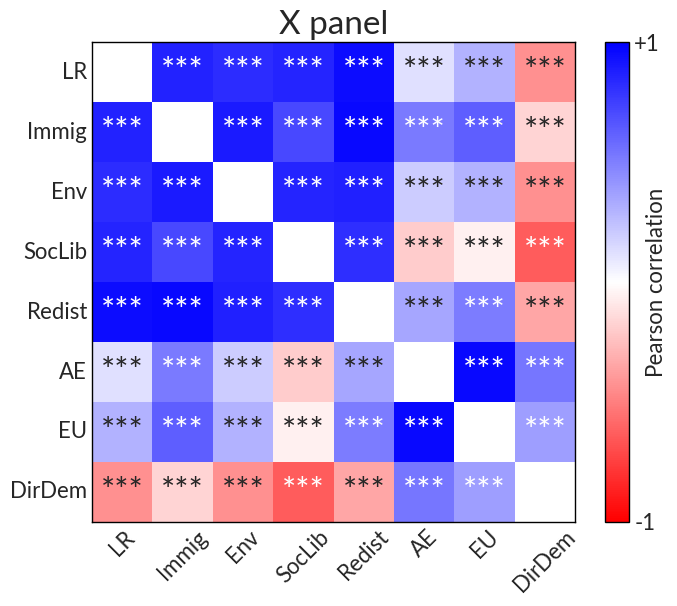

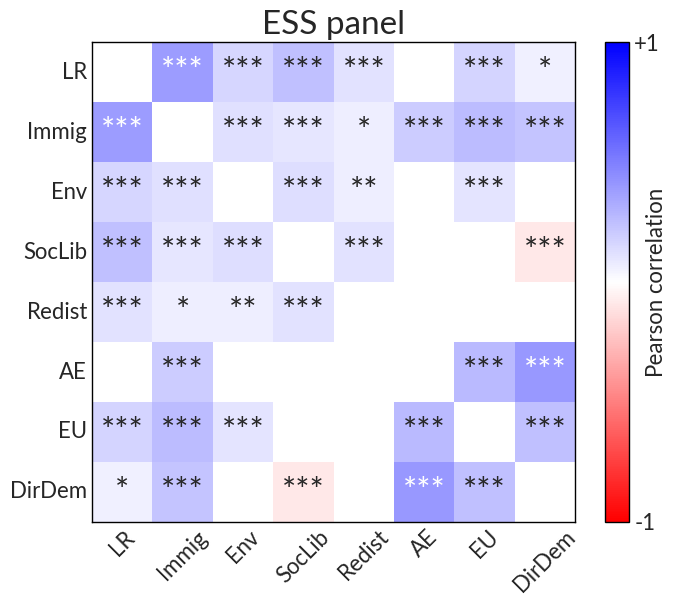

In [45]:
nan_color = 'w'

for name in ('X', 'ESS'):

    fig,ax = plt.subplots(figsize=(7,6))

    df = df_corr[name].mask(np.eye(df_corr[name].shape[0], dtype=bool)).mask(df_pval[name]>.05)

    cmap = plt.get_cmap('bwr_r').copy()
    cmap.set_bad(color=nan_color)
    sns.heatmap(df, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
                annot=significance_matrix[name].values, fmt='', cbar=True, ax=ax, annot_kws={'fontsize':24}) # set annot=False to remove significance levels

    # Get the colorbar and add border
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(True)           # show border
    cbar.outline.set_edgecolor('black')      # border color
    cbar.outline.set_linewidth(1)          # border thickness
    cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
    cbar.set_ticklabels(['-1', '+1'])
    cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

    # esthetics
    ax.set_title(DataLabel[name], fontsize=24)
    ax.tick_params(axis='x', labelsize=16, rotation=45)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xticklabels([short_label[dim] for dim in Dimensions])
    ax.set_yticklabels([short_label[dim] for dim in Dimensions])
    ax.tick_params(axis='both', length=0)

    for pos in ('top', 'bottom', 'left', 'right'):
      ax.spines[pos].set_visible(True)
      ax.spines[pos].set_color('k')
      ax.spines[pos].set_linewidth(1)

    # save
    plt.tight_layout(pad=.5)
    plt.savefig(figpath + f'correlation_{name}.png', dpi=300)
    plt.show()
    plt.close()

Compare ingroup and outgroup correlations.

In [46]:
X_ingroup_avg_corr = np.mean(list(df_corr['X'].abs().values[:5,:5][np.triu_indices(5,1)]) + list(df_corr['X'].abs().values[-3:,-3:][np.triu_indices(3,1)]))
X_outgroup_avg_corr = np.mean(df_corr['X'].abs().values[:5,-3:])

In [47]:
X_ingroup_avg_corr, X_outgroup_avg_corr, X_ingroup_avg_corr / X_outgroup_avg_corr

(0.8068558771506091, 0.34701229835105246, 2.3251506675257927)

In [48]:
ESS_ingroup_avg_corr = np.mean(list(corrmat_ESS.abs().values[:5,:5][np.triu_indices(5,1)]) + list(corrmat_ESS.abs().values[-3:,-3:][np.triu_indices(3,1)]))
ESS_outgroup_avg_corr = np.mean(corrmat_ESS.abs().values[:5,-3:])

In [49]:
ESS_ingroup_avg_corr, ESS_outgroup_avg_corr, ESS_ingroup_avg_corr / ESS_outgroup_avg_corr

(0.18621562527806562, 0.08914929576512848, 2.088806464255946)

# Perform PCA

In [50]:
pca_df, explained_variance, loadings = dict(), dict(), dict()

In [51]:
n_components = len(Dimensions)

## X panel

Standardize the data.

In [52]:
df_scaled = StandardScaler().fit_transform(df_x[Dimensions]) 

Apply PCA.

In [53]:
pca = PCA(n_components = n_components)  # Keep all components
principal_components = pca.fit_transform(df_scaled)

Create dataframe with individual coordinates along principal components.

In [54]:
columns = [f'PC{i+1}' for i in range(n_components)]

In [55]:
pca_df['X'] = pd.DataFrame(principal_components, columns=columns)

Explained variance.

In [56]:
explained_variance['X'] = pca.explained_variance_ratio_

Loadings.

In [57]:
loadings['X'] = pd.DataFrame(pca.components_.T, columns=columns, index=Dimensions)

Append PCA coordinates to X dataframe.

In [58]:
df_x.loc[:, columns] = pca_df['X'][columns]

Clean memory.

In [59]:
del df_scaled

## ESS panel

For ESS we just load the results obtained in R.

Loadings.

In [60]:
loadings['ESS'] = pd.read_csv(ess_path + 'PCA_loadings.csv')

In [61]:
# esthetic adjustments

loadings['ESS']['Variable'] = [d.replace('.', ' ') for d in loadings['ESS']['Variable'].values]
loadings['ESS']['Variable'] = loadings['ESS']['Variable'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
loadings['ESS'] = loadings['ESS'].set_index(loadings['ESS']['Variable'].values)
loadings['ESS'] = loadings['ESS'].drop(columns = 'Variable')

Explained variance.

In [62]:
explained_variance['ESS'] = pd.read_csv(ess_path + 'PCA_explained_variance.csv')

In [63]:
explained_variance['ESS'] = explained_variance['ESS']['Proportion'].values
explained_variance['ESS'] = explained_variance['ESS']/explained_variance['ESS'].sum()

Individual coordinates along principal components.

In [64]:
pca_df['ESS'] = pd.read_csv(ess_path + 'PCA_coordinates.csv')
df_ess.loc[:, columns] = pca_df['ESS'][columns].values

## Rotate and reflect PC1 and PC2

We use varimax rotation.

In [65]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [66]:
rotated_loadings = dict()
rotation_matrix = dict()

for name in ('X', 'ESS'):
    rotated_loadings[name], rotation_matrix[name] = functions.varimax(loadings[name][PCaxes])
    rotated_loadings[name] = pd.DataFrame(rotated_loadings[name], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [67]:
df_x[[p+'_rot' for p in PCaxes]] = np.dot(df_x[Dimensions], rotated_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_rot' for p in PCaxes]] = np.dot(df_ess[Dimensions], rotated_loadings['ESS'])  # shape: (n_samples, n_components)

Reflect axes for ESS. For the X panel we just copy the rotated loadings.

In [68]:
reflected_loadings = dict()

for name in ('X', 'ESS'):
    reflected_loadings[name] = pd.DataFrame(rotated_loadings[name]).rename(columns={'PC1_rot': 'PC1_ref', 'PC2_rot': 'PC2_ref'})
    
values = np.array([[0,-1],[1,0]]).dot(rotated_loadings['ESS'].values.T)
reflected_loadings['ESS']['PC1_ref'] = values[0]
reflected_loadings['ESS']['PC2_ref'] = -values[1]

Add positions along the reflected axes to the dataframes.

In [69]:
df_x[[p+'_ref' for p in PCaxes]] = np.dot(df_x[Dimensions], reflected_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_ref' for p in PCaxes]] = np.dot(df_ess[Dimensions], reflected_loadings['ESS'])  # shape: (n_samples, n_components)

# Explained variance and effective dimensionality
Figure 3.

Compute effective dimensionality.

In [70]:
ED = {'ESS': functions.effective_dimensionality_from_corrmat(corrmat_ESS),
      'X': functions.effective_dimensionality_from_corrmat(df_x[Dimensions].corr().values)}

print(ED)

{'ESS': 7.27867607484876, 'X': 2.5540042490773036}


Show explained variance.

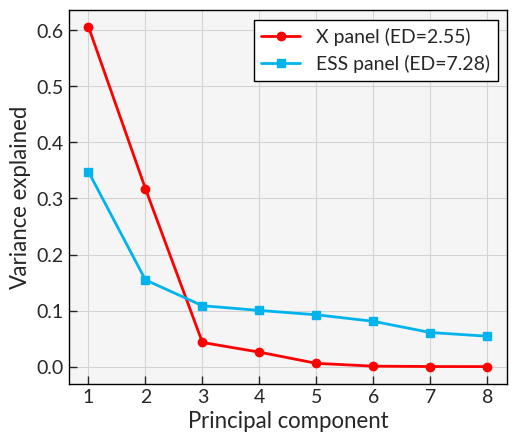

In [71]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X','ESS')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name], lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'explained_variance.png', dpi=300)
plt.show()
plt.close()

Show cumulated explained variance.

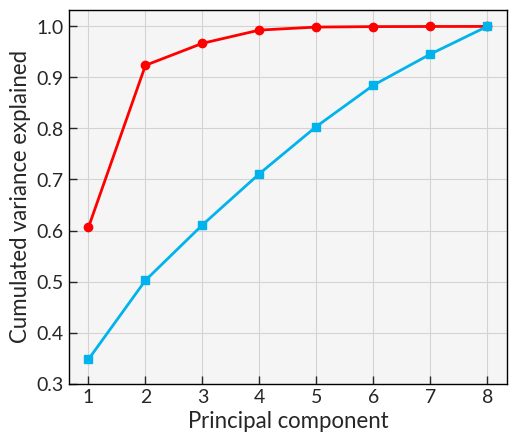

In [72]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X', 'ESS')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name].cumsum(), lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Cumulated variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.yticks(np.arange(3,11)/10)
plt.grid(axis='both', color='lightgrey')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'explained_variance_cumul.png', dpi=300)
plt.show()
plt.close()

# Loadings of political dimensions in the PCA space
Figure 4.

We plot the coordinates of the political dimensions in the (PC1,PC2) space, with and without labels.

X


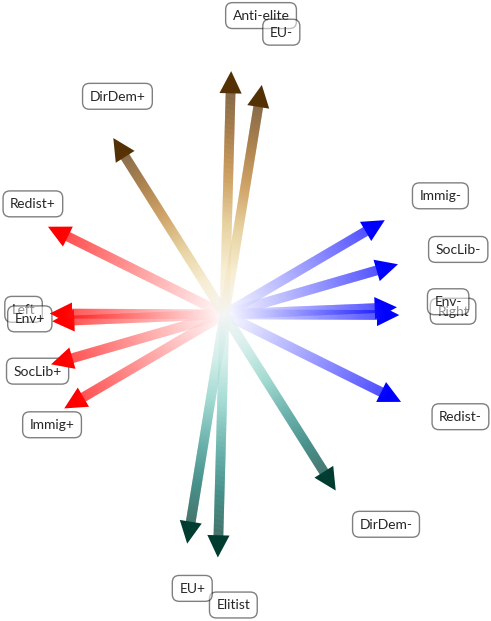

ESS


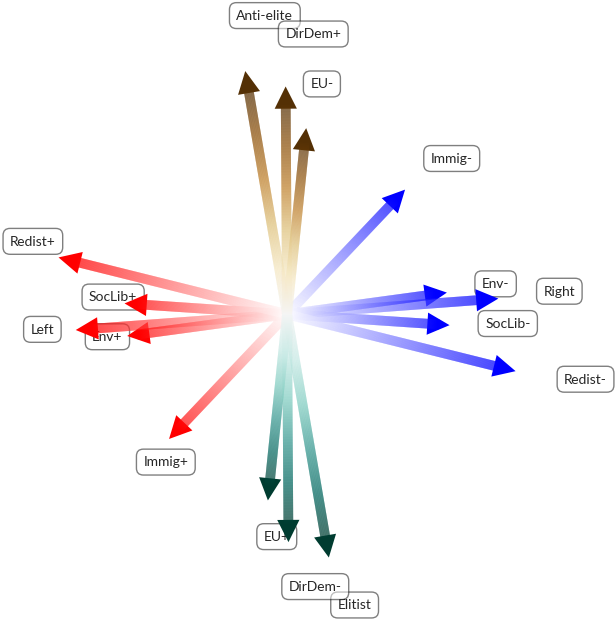

X


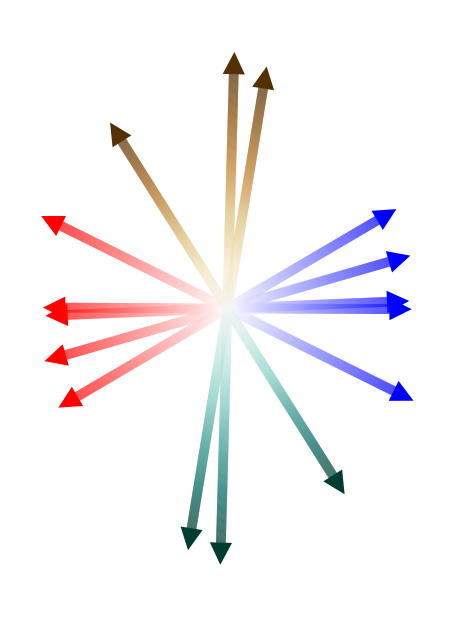

ESS


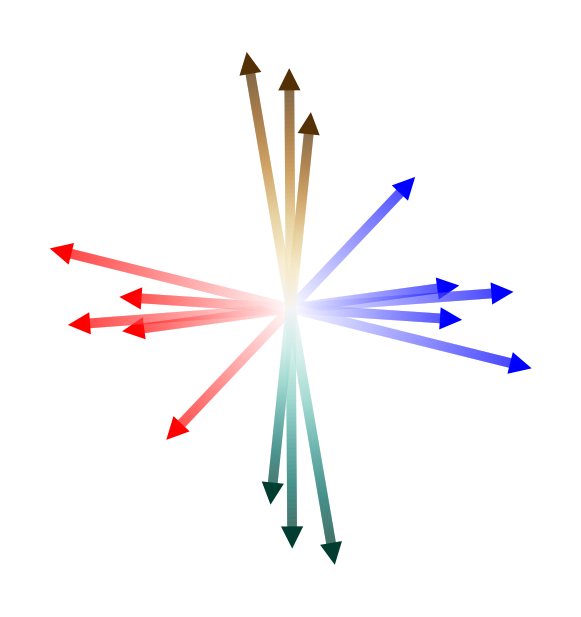

In [73]:
scale = 1.3

for text in (True,False):

    for name in ('X', 'ESS'):
        print(name)
        fig, ax = plt.subplots(figsize=(6,6))
        xmax, ymax = 0, 0

        for dim in Dimensions:
            x = reflected_loadings[name].loc[dim]['PC1_ref']
            y = reflected_loadings[name].loc[dim]['PC2_ref']

            if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
                cmap = 'BrBG_r'
                zorder = 10
            else:
                cmap = 'bwr_r'
                zorder = 10
            xmax = max(abs(x), abs(xmax))
            ymax = max(abs(y), abs(ymax))
            ax = functions.draw_arrow_bidim(x, y, ax, scale=1.085, center=0, cmap=cmap, zorder=zorder)

            if text:
                ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
                ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

        ax.set_xlim(-1.25*xmax, 1.25*xmax)
        ax.set_ylim(-1.25*ymax, 1.25*ymax)
        ax.set_aspect('equal')
        plt.axis('off')

        plt.tight_layout(pad=.1)

        if text:
            plt.savefig(figpath + f'sun_{name}_text.png', dpi=300)
        else:
            plt.savefig(figpath + f'sun_{name}.png', dpi=300)

        plt.show()
        plt.close()

# 3D distributions of panelists in PCA space
Figure 5.

First we plot for X panel.

/tmp/ipykernel_2241382/3822370053.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/3822370053.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


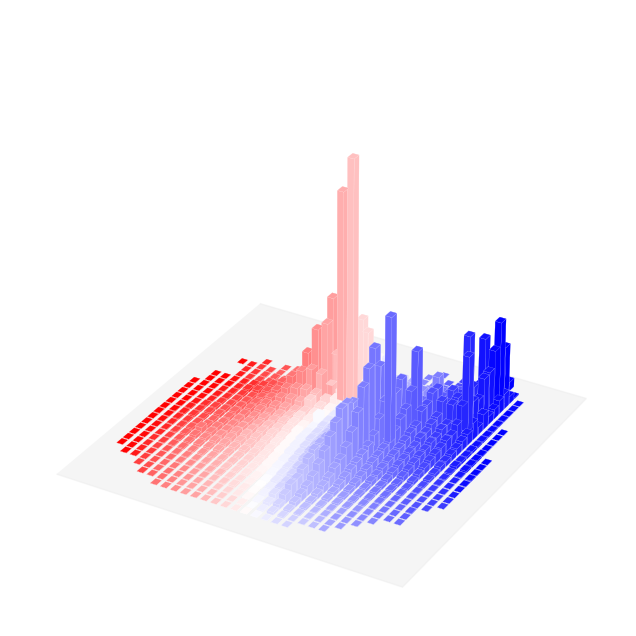

/tmp/ipykernel_2241382/3822370053.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/3822370053.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


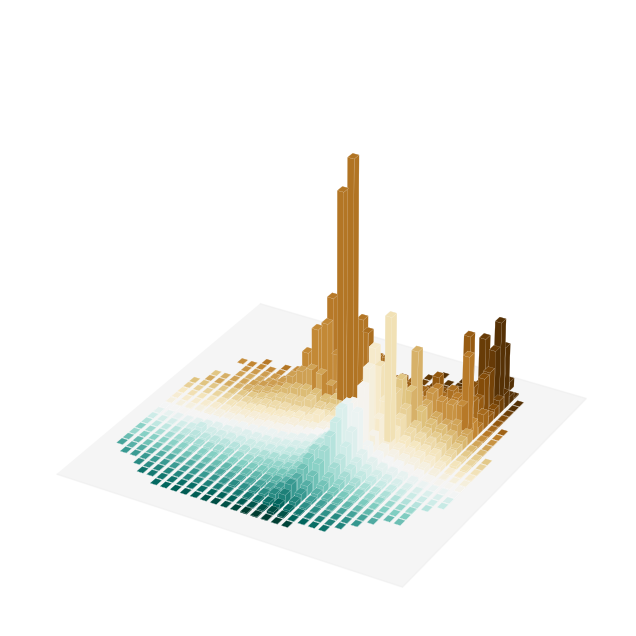

In [74]:
for dim in ('Left-Right','Anti-elitism'):
    
    # ensure df_tmp is a DataFrame
    df_tmp = pd.DataFrame(df_x)
    n_bins = 30

    # bin PCs
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins)

    # bin centers
    df_tmp['PC1_center'] = df_tmp['PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 2))
    df_tmp['PC2_center'] = df_tmp['PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 2))

    # aggregate mean(dim) and count
    agg_df = (
        df_tmp
        .groupby(['PC1_center', 'PC2_center'])
        .agg(mean_dim=(dim, 'mean'), count=('PC1', 'size'))
        .reset_index()
    )

    # remove empty bins
    agg_df = agg_df[agg_df['count'] > 0].copy()

    # create grid
    X = agg_df['PC1_center'].values
    Y = agg_df['PC2_center'].values
    Z = np.zeros_like(X)
    dz = agg_df['count'].values

    # choose colormap based on your existing rule
    cmap = 'BrBG_r' if dim in ('Anti-elitism', 'EU integration', 'Direct democracy') else 'bwr_r'

    # normalize dim values to [0,1] for color mapping
    norm = plt.Normalize(agg_df['mean_dim'].min(), agg_df['mean_dim'].max())
    colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))

    # bar width
    dx = dy = (df_tmp['PC1'].max() - df_tmp['PC1'].min()) / n_bins

    # plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.bar3d(X, Y, Z, dx, dy, dz, color=colors, edgecolor='w', linewidth=.1, shade=False, alpha=1)

    ax.tick_params(size=0)

    # remove 3D grid, background panes and axis lines
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.savefig(figpath + f'3D_x_{dim}.png', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

Now for ESS panel.

/tmp/ipykernel_2241382/1721636004.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/1721636004.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


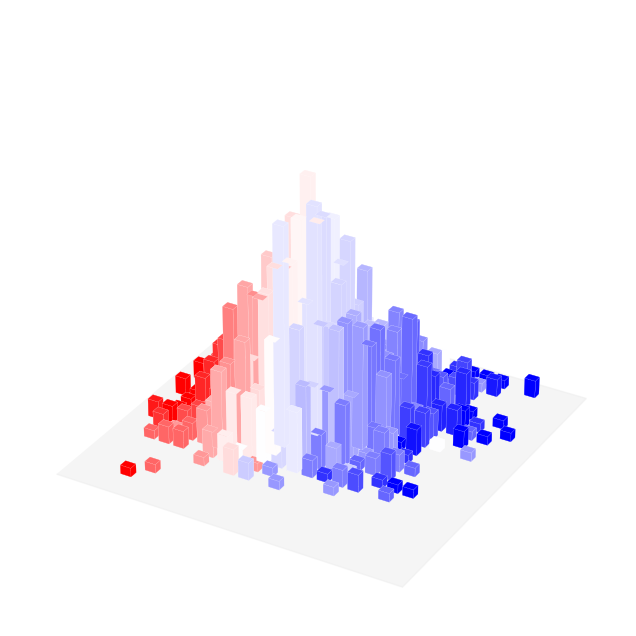

/tmp/ipykernel_2241382/1721636004.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['PC1_center', 'PC2_center'])
/tmp/ipykernel_2241382/1721636004.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))


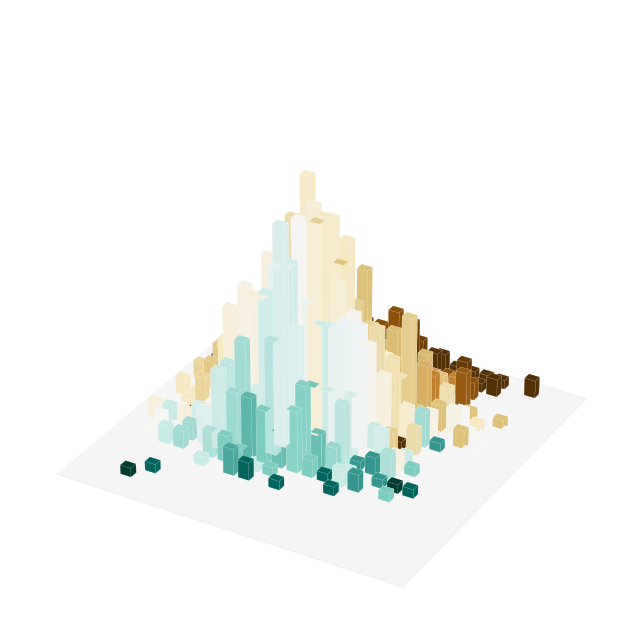

In [75]:
for dim in ('Left-Right','Anti-elitism'):
    
    # ensure df_tmp is a DataFrame
    df_tmp = pd.DataFrame(df_ess)
    n_bins = 20

    # bin PCs
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins)

    # bin centers
    df_tmp['PC1_center'] = df_tmp['PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 2))
    df_tmp['PC2_center'] = df_tmp['PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 2))

    # aggregate mean(dim) and count
    agg_df = (
        df_tmp
        .groupby(['PC1_center', 'PC2_center'])
        .agg(mean_dim=(dim, 'mean'), count=('PC1', 'size'))
        .reset_index()
    )

    # remove empty bins
    agg_df = agg_df[agg_df['count'] > 0].copy()

    # create grid
    X = agg_df['PC1_center'].values
    Y = agg_df['PC2_center'].values
    Z = np.zeros_like(X)
    dz = agg_df['count'].values

    # choose colormap based on your existing rule
    cmap = 'BrBG_r' if dim in ('Anti-elitism', 'EU integration', 'Direct democracy') else 'bwr_r'

    # normalize dim values to [0,1] for color mapping
    norm = plt.Normalize(agg_df['mean_dim'].min(), agg_df['mean_dim'].max())
    colors = cm.get_cmap(cmap)(norm(agg_df['mean_dim'].values))

    # bar width
    dx = dy = (df_tmp['PC1'].max() - df_tmp['PC1'].min()) / n_bins

    # plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.bar3d(X, Y, Z, dx, dy, dz, color=colors, edgecolor='w', linewidth=.1, shade=False, alpha=1)

    ax.tick_params(size=0)

    # remove 3D grid, background panes and axis lines
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent
    ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Transparent


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.savefig(figpath + f'3D_ess_{dim}.png', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

# Variations with activity and popularity
Figure 6.

In [76]:
figsize = (5,4) # for plots

In [77]:
Metrics = ('activity', 'popularity')

Set up bins and bin labels for each metric.

In [78]:
bins, ticklabels, bin_labels = dict(), dict(), dict()

bins['activity'] = [-np.inf, 0, .01, .1, 1, 10, 100, np.inf]
ticklabels['activity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{0.01}$',
        '$\\mathdefault{0.01}$-$\\mathdefault{0.1}$',
        '$\\mathdefault{0.1}$-$\\mathdefault{1}$',
        '$\\mathdefault{1}$-$\\mathdefault{10}$',
        '$\\mathdefault{10}$-$\\mathdefault{100}$',
        '>$\\mathdefault{100}$',
        ]
bin_labels['activity'] = [f"({bins['activity'][i]}, {bins['activity'][i+1]})" for i in range(len(bins['activity'])-1)]
    
bins['popularity'] = [-np.inf, 0, 10, 100, 1000, 10000, 100000, np.inf]
ticklabels['popularity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{10^1}$',
        '$\\mathdefault{10^1}$-$\\mathdefault{10^2}$',
        '$\\mathdefault{10^2}$-$\\mathdefault{10^3}$',
        '$\\mathdefault{10^3}$-$\\mathdefault{10^4}$',
        '$\\mathdefault{10^4}$-$\\mathdefault{10^5}$',
        '>$\\mathdefault{10^5}$',
        ]
bin_labels['popularity'] = [f"({bins['popularity'][i]}, {bins['popularity'][i+1]})" for i in range(len(bins['popularity'])-1)]

Sort users into bins by activity and by popularity.

In [79]:
df_x['activity_bin'] = pd.cut(df_x['mean_tweets_per_day'], bins=bins['activity'], labels=bin_labels['activity'])
df_x['popularity_bin'] = pd.cut(df_x['followers'], bins=bins['popularity'], labels=bin_labels['popularity'])

Plot effective dimensionality, depending on activity or popularity.

/tmp/ipykernel_2241382/3534221472.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels['activity'])
/tmp/ipykernel_2241382/3534221472.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(ticklabels['popularity'])


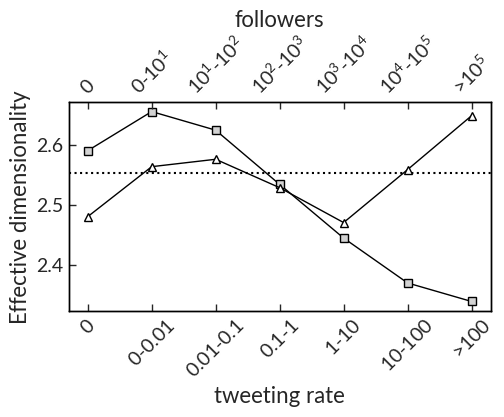

In [80]:
fig,ax = plt.subplots(figsize=figsize)

# value with all users
ax.axhline(functions.effective_dimensionality(df_x, Dimensions), color='k', ls=':', label='All users')

# for activity
effective_dim = [functions.effective_dimensionality(df_x[df_x['activity_bin']==bl], Dimensions) for bl in bin_labels['activity']]
ax.plot(bin_labels['activity'], effective_dim, color='k', lw=1, marker='s', markerfacecolor='lightgrey', label=f'tweeting rate', zorder=100)
ax.set_xticklabels(ticklabels['activity'])
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('tweeting rate')
ax.set_ylabel(r'Effective dimensionality')

# for popularity
ax_ = ax.twiny()
effective_dim = [functions.effective_dimensionality(df_x[df_x['popularity_bin']==bl], Dimensions) for bl in bin_labels['popularity']]
ax_.plot(bin_labels['popularity'], effective_dim, color='k', lw=1, marker='^', markerfacecolor='w', label=f'followers', zorder=10)
ax_.set_xlabel('followers')
ax_.tick_params(axis='x', rotation=45)
ax_.set_xticklabels(ticklabels['popularity'])

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
    ax_.spines[pos].set_visible(True)
    ax_.spines[pos].set_color('k')
    ax_.spines[pos].set_linewidth(1)
ax.tick_params(length=5, direction='in')
ax_.tick_params(length=5, direction='in')

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + 'actipop_ED.png', dpi=300)
plt.show()
plt.close()

Distribution of positions for a chosen dimension (e.g., EU integration).

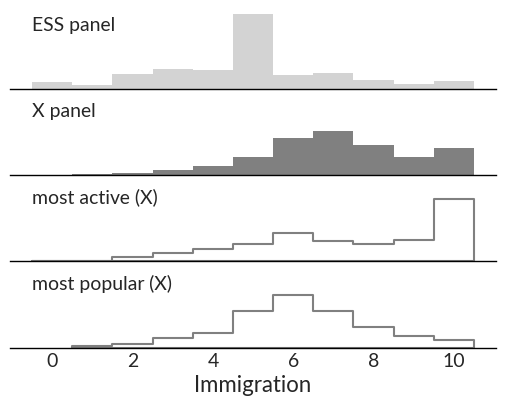

In [88]:
dim = 'Immigration'

names_ = ('ESS panel', 'X panel', 'most active (X)', 'most popular (X)')

n_bins = len(ess_label_range[dim])

fig, axes = plt.subplots(4, 1, figsize=(5,4), sharey=True, sharex=True)

# ESS
sns.histplot(data=functions.get_ess_counts(ess_counts_full, dim), x='bin', weights='count', bins=n_bins, color='lightgrey', edgecolor='none', alpha=1, discrete=True, ax=axes[0])

# X
sns.histplot(data=functions.get_x_counts(df_x, dim), x='bin', weights='count', bins=n_bins, color='grey', edgecolor='none',alpha=1,discrete=True, ax=axes[1])

# X (most active)
sns.histplot(data=functions.get_x_counts(df_x[df_x['activity_bin']=='(100, inf)'], dim), x='bin', weights='count', element='step',bins=n_bins,color='none', alpha=1, lw=1.5, edgecolor='grey', discrete=True, fill=True, ax=axes[2])

# X (most popular)
sns.histplot(data=functions.get_x_counts(df_x[df_x['popularity_bin']=='(100000, inf)'], dim), x='bin', weights='count',element='step', bins=n_bins, color='none', alpha=1, lw=1.5, edgecolor='grey', discrete=True, fill=True, ax=axes[3])

# esthetics
for k in range(4):
    axes[k].set_ylabel('')
    xlabel = dim if k==3 else ''
    axes[k].set_xlabel(xlabel)
    axes[k].tick_params(axis='x', length=0)
    axes[k].text(x=-.5, y=.3, s=names_[k], fontsize=14)
    axes[k].yaxis.set_visible(False)

    for pos in ( 'bottom', ):
        axes[k].spines[pos].set_visible(True)
        axes[k].spines[pos].set_color('k')
        axes[k].spines[pos].set_linewidth(1)
    for pos in ( 'top', 'left', 'right'):
        axes[k].spines[pos].set_visible(False)

plt.tight_layout(pad=.5)
plt.savefig(figpath + f'actipop_{dim}_hist.png', dpi=300)
plt.show()
plt.close()

Average positions of users along PC1 and PC2, depending on activity or popularity.

/tmp/ipykernel_2241382/1748545564.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2241382/1748545564.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


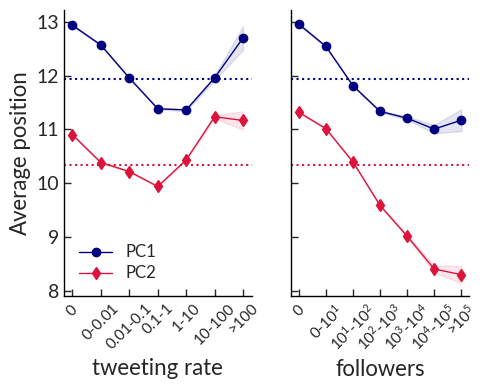

In [82]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
color = {'PC1_ref':'navy', 'PC2_ref':'crimson'}
marker = {'PC1_ref':'o', 'PC2_ref':'d'}
label_ = {'PC1_ref':'PC1', 'PC2_ref':'PC2'}

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    #ax.axhline(effective_dim_base, color='k', ls=':', label='All users')
    for PCdim in ('PC1_ref','PC2_ref'):
        ax.axhline(y=df_x[PCdim].mean(), color=color[PCdim], ls=':', zorder=-100)# label=PCdim[:-4]+' (all users)')

        PC_avg = [df_x[df_x[metric+'_bin']==bl][PCdim].mean() for bl in bin_labels[metric]]
        ax.plot(bin_labels[metric], PC_avg, color=color[PCdim], lw=1, marker=marker[PCdim], label=label_[PCdim])

        ci_lower, ci_upper = list(), list()
        for bl in bin_labels[metric]:
            mean = df_x[df_x[metric+'_bin']==bl][PCdim].mean()
            sem = stats.sem(df_x[df_x[metric+'_bin']==bl][PCdim].values)
            ci_lower.append(mean - z*sem)
            ci_upper.append(mean + z*sem)
        ax.fill_between(bin_labels[metric], ci_lower, ci_upper, color=color[PCdim], alpha=.1, zorder=-10)

    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Average position' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # axe lines
    for pos in ('bottom', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)

    ax.tick_params(length=5, direction='in')

    if i==0:
        ax.legend(loc='best', ncols=1, frameon=False, framealpha=1, labelspacing=.3, shadow=True, fontsize=12)

plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'actipop_PC12.png', dpi=300)
plt.show()
plt.close()

Average correlation between positions on PCs.

/tmp/ipykernel_2236545/3689649594.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/3689649594.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


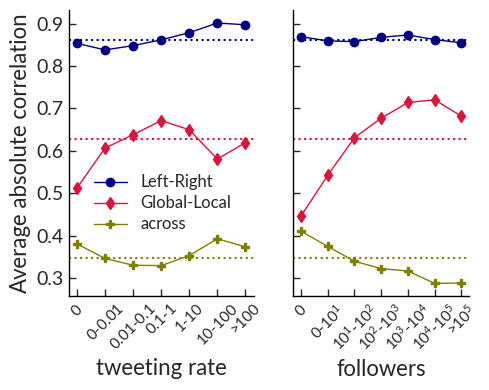

In [79]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    # left-right
    baseline = df_x[Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='navy', ls=':', zorder=-100)#, label='Left-Right (all users)')
    ax.plot(bin_labels[metric], corr, color='navy', lw=1, marker='o', label='Left-Right')

    # global-local
    baseline = df_x[Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='crimson', ls=':', zorder=-100)#, label='Global-Local (all users)')
    ax.plot(bin_labels[metric], corr, color='crimson', lw=1, marker='d', label='Global-Local')

    # across
    baseline = df_x[Dimensions].corr().abs().values[:5,-3:].mean()
    corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,-3:].mean() for bl in bin_labels[metric]]
    ax.axhline(y=baseline, color='olive', ls=':', zorder=-100)#, label='across (all users)')
    ax.plot(bin_labels[metric], corr, color='olive', lw=1, marker='P', label='across')

    # esthetics
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Average absolute correlation' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    for pos in ('bottom', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)

    ax.tick_params(length=5, direction='in')

    if i==0:
        ax.legend(loc=(.1,.2), ncols=1, frameon=False, labelspacing=.3, shadow=False, fontsize=12)


plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'actipop_corr.png', dpi=300)
plt.show()
plt.close()

Polarization and Wasserstein distance (WD) across activity and popularity bins.

In [80]:
pola = {m: {dim: list() for dim in Dimensions} for m in('activity','popularity')}
WD = {m: {dim: list() for dim in Dimensions} for m in ('activity','popularity')}

for m in ('activity','popularity'):

    for bl in bin_labels[m]:
        df_tmp = df_x[df_x[m+'_bin']==bl]

        # pola and WD
        for dim in Dimensions:
            x_counts = functions.get_x_counts(df_tmp, dim)
            pola[m][dim].append(functions.polarization_from_counts_df(x_counts))

            # WD 
            ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
            x_counts = functions.get_x_counts(df_tmp, dim).sort_values(by='bin')
            mini = np.min(ess_label_range[dim])
            maxi = np.max(ess_label_range[dim])
            wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
            wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
            wd = wd / wd_max
            WD[m][dim].append(wd)

Get baselines, computed on the whole dataset.

In [81]:
pola_baseline = dict()
wd_baseline = dict()

for dim in Dimensions:
    x_counts = functions.get_x_counts(df_x, dim)
    pola_baseline[dim] = functions.polarization_from_counts_df(x_counts)

    # WD 
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
    x_counts = functions.get_x_counts(df_x, dim).sort_values(by='bin')
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    wd = wd / wd_max
    wd_baseline[dim] = wd

Plot polarization.

/tmp/ipykernel_2236545/3801262146.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/3801262146.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


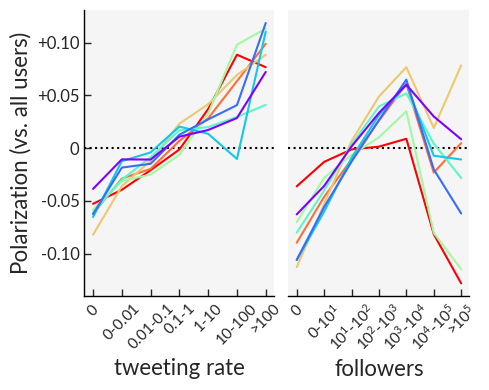

In [82]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
marker = {'activity':'s', 'popularity':'^'}
cmap = plt.get_cmap('rainbow_r')

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    # plot
    ax.axhline(y=0, ls=':', color='k',  lw=1.5)
    for j,dim in enumerate(Dimensions):
        c = cmap(j/(len(Dimensions)-1))
        diff = np.array(pola[metric][dim]-pola_baseline[dim])
        ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

    # esthetics
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = 'Polarization (vs. all users)' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=5, direction='in')

    for pos in ('bottom', 'top', 'right', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)
    if i==1:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)
    ax.set_facecolor('whitesmoke')

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout(w_pad=.2)
plt.savefig(figpath + f'actipop_pola.png', dpi=300)
plt.show()
plt.close()

Plot Wasserstein distance.

/tmp/ipykernel_2236545/1720713530.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)
/tmp/ipykernel_2236545/1720713530.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


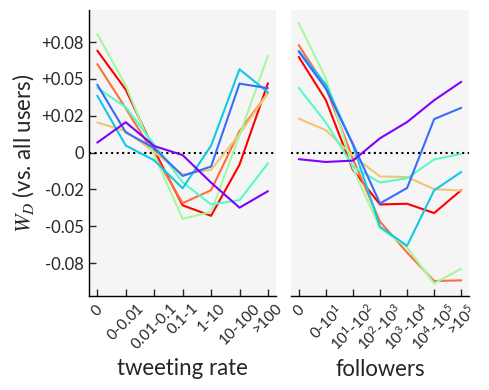

In [83]:
fig,axes = plt.subplots(1, 2, figsize=(5,4), width_ratios=[1.05,1], sharey=True)
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
marker = {'activity':'s', 'popularity':'^'}
cmap = plt.get_cmap('rainbow_r')

for i,metric in enumerate(('activity','popularity')):

    ax = axes[i]

    ax.axhline(y=0, ls=':', color='k',  lw=1.5)
    for j,dim in enumerate(Dimensions):
        c = cmap(j/(len(Dimensions)-1))
        diff = np.array(WD[metric][dim]-wd_baseline[dim])
        ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticklabels(ticklabels[metric], fontsize=11)

    xlabel = 'tweeting rate' if metric=='activity' else 'followers'
    ylabel = r'$W_D$ (vs. all users)' if i==0 else ''
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=5, direction='in')

    # axe lines
    for pos in ('bottom', 'top', 'right', 'left'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    for pos in ('top', 'right'):
        ax.spines[pos].set_visible(False)
    if i==1:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)
    ax.set_facecolor('whitesmoke')

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout(w_pad=.2)
plt.savefig(figpath + f'actipop_wd.png', dpi=300)
plt.show()
plt.close()

# Analysis of X panel weighted by users' visibility
Figure 7.

In [84]:
Marker['Visibility'] = '^'
DataLabel['Visibility'] = 'X panel (weighted)'
df_color['Visibility'] = 'limegreen'
name_vis = 'Visibility'

In [85]:
df_x['visibility'] = df_x['mean_tweets_per_day'] * df_x['followers']

In [86]:
df_visibility = df_x[~df_x['visibility'].isna()]

## Analyze

We use the `weighted=True` parameter of our custom function `functions.get_x_counts`, which takes into accounts individual weights to return user counts within bins.

Dimension-wise distributions.

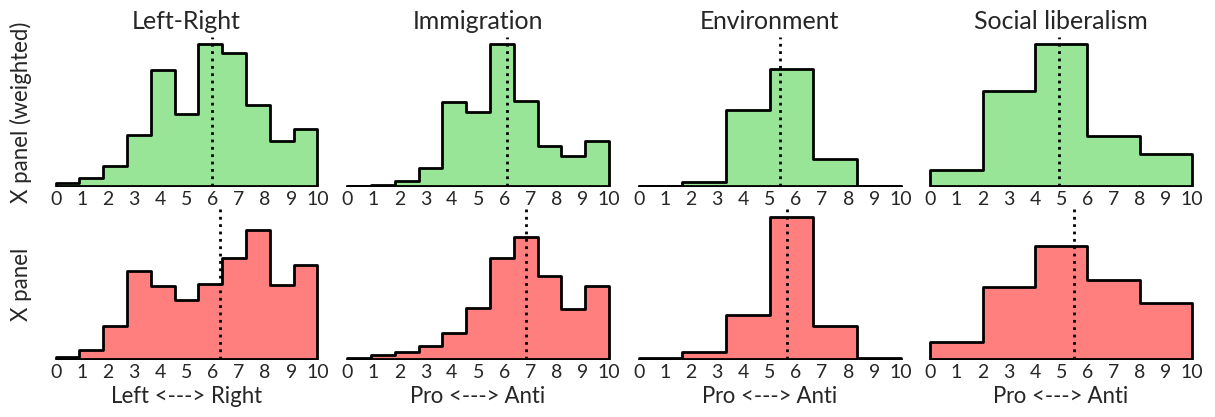

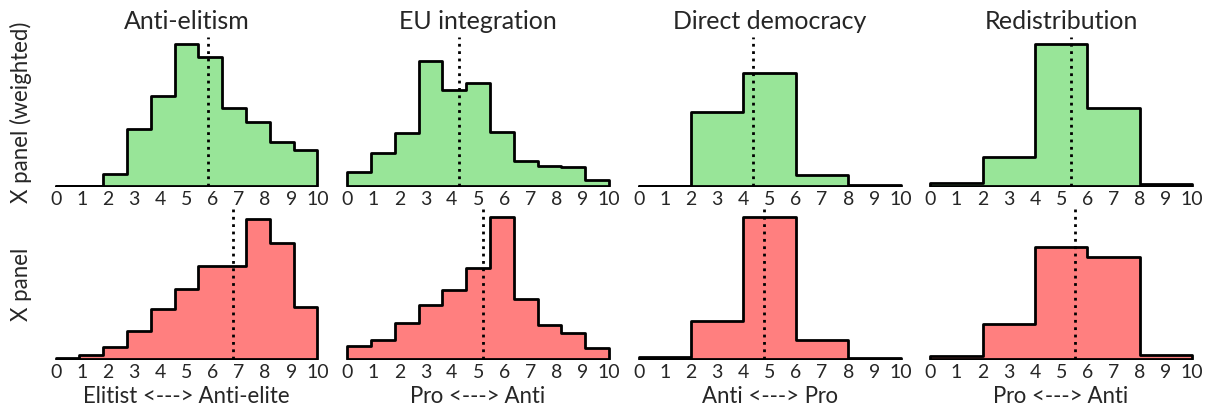

In [90]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Count bin occurrences, weighted and non-weighted
        Counts['Visibility'] = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility')
        Counts['X'] = functions.get_x_counts(df_x, dim, weighted=False)

        # compute WS
        mini = np.min(ess_label_range[dim])
        maxi = np.max(ess_label_range[dim])
        ws_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
        ws = stats.wasserstein_distance(Counts['Visibility']['bin'], Counts['X']['bin'], Counts['Visibility']['count'], Counts['X']['count'])
        ws = ws / ws_max

        for j,label in enumerate(('Visibility', 'X')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot hist
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label],  edgecolor='none', discrete=True, alpha=.5, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', discrete=True, alpha=.5, ax=ax)

            # esthetics
            if label=='Visibility':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            if j==1:
                ax.set_xticks(xticks1, xticks2)
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'visibility_histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Polarization.

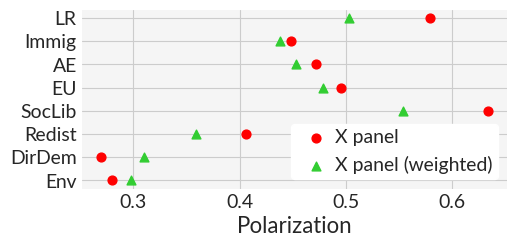

In [88]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_visibility = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_visibility, dim, weighted=False)
    visibility_counts = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility')
    
    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_visibility = functions.polarization_from_counts_df(visibility_counts)

    # append
    data_x['Dimension'].append(dim)
    data_visibility['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_visibility['Polarization'].append(pola_visibility)

# create dfs
data_x = pd.DataFrame(data_x)
data_visibility = pd.DataFrame(data_visibility)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label=DataLabel['X'])
plt.scatter(data_visibility['Polarization'], data_visibility['Dimension'], color=df_color['Visibility'], marker=Marker['Visibility'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)

plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='w', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'visibility_polarization.png', dpi=300)
plt.show()
plt.close()

Wasserstein distance with ESS panel.

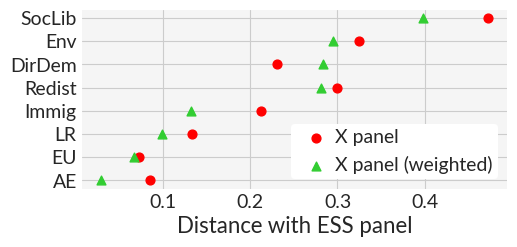

In [89]:
# Combine all data into one list
data_x = {'Dimension':list(), 'Distance':list()}
data_visibility = {'Dimension':list(), 'Distance':list()}

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_visibility, dim, weighted=False).sort_values(by='bin')
    visibility_counts = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility').sort_values(by='bin')
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute wd
    wd_x = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count']) / wd_max
    wd_visibility = stats.wasserstein_distance(visibility_counts['bin'], ess_counts['bin'], visibility_counts['count'], ess_counts['count']) / wd_max

    # append
    data_x['Dimension'].append(dim)
    data_visibility['Dimension'].append(dim)
    data_x['Distance'].append(wd_x)
    data_visibility['Distance'].append(wd_visibility)

# create dfs
data_x = pd.DataFrame(data_x)
data_visibility = pd.DataFrame(data_visibility)

# sort
data_visibility = data_visibility.sort_values(by='Distance', ascending=True)
data_x = data_x.set_index('Dimension').loc[data_visibility['Dimension']].reset_index()

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Distance'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label='X panel')
plt.scatter(data_visibility['Distance'], data_visibility['Dimension'], color=df_color['Visibility'], marker=Marker['Visibility'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)
plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='none', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Distance with ESS panel')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'visibility_WD.png', dpi=300)
plt.show()
plt.close()